In [15]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HTTP_PROXY"]= "http://proxy.utwente.nl:3128"
os.environ["HTTPS_PROXY"]= "http://proxy.utwente.nl:3128"
os.environ["http_proxy"]= "http://proxy.utwente.nl:3128"
os.environ["https_proxy"]= "http://proxy.utwente.nl:3128"

Create sentence and related ttp in json

import json
from collections import defaultdict
from pathlib import Path
# =========================
# CONFIG
# =========================
INPUT_FILE = "../../data_augmentatio_stefano/mitre/cleaned_capec.json"      # your provided dataset
OUTPUT_FILE = "../../data_augmentatio_stefano/mitre/only_sentence_to_ttp.json"   # output
MIN_SENT_LEN = 0                            # filter junk if needed
# =========================

def normalize_sentence(s: str) -> str:
    """Light normalization to avoid trivial duplicates."""
    return " ".join(s.strip().split())

def main():
    with open(INPUT_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)

    sent_to_labels = defaultdict(set)

    for row in data:
        sent = row.get("relationship_description", "")
        tech = row.get("technique_id", "")

        if not sent or not tech:
            continue

        sent = normalize_sentence(sent)
        sent_to_labels[sent].add(tech)

    # Convert to list format
    output = [
        {
            "sentence": sent,
            "labels": sorted(list(labels))
        }
        for sent, labels in sent_to_labels.items()
    ]

    print(f"✅ Sentences: {len(output)}")
    print(f"✅ Unique TTPs: {len({l for o in output for l in o['labels']})}")

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"📁 Saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()


Add tram and bosch

import json
import re
from collections import defaultdict
# =========================
# CONFIG
# =========================
BASE_FILE = "../../data_augmentatio_stefano/mitre/only_sentence_to_ttp.json"      # from previous step
ADDITIONAL_FILE = "../../data_augmentatio_stefano/tram_bosch/bosch_test.json"
OUTPUT_FILE = "../../data_augmentatio_stefano/mitre/only_sentence_to_ttp.json"

KEEP_TACTICS = False   # set True if you want TAxxxx labels
# =========================

TTP_RE = re.compile(r"^T\d{4}(\.\d{3})?$")
TACTIC_RE = re.compile(r"^TA\d{4}$")

def normalize_sentence(s: str) -> str:
    return " ".join(s.strip().split())

def filter_labels(labels):
    out = set()
    for l in labels:
        if TTP_RE.match(l):
            out.add(l)
        elif KEEP_TACTICS and TACTIC_RE.match(l):
            out.add(l)
    return out

def main():
    # -------------------------------------------------
    # Load base dataset
    # -------------------------------------------------
    with open(BASE_FILE, "r", encoding="utf-8") as f:
        base_data = json.load(f)

    sent_to_labels = defaultdict(set)

    for row in base_data:
        sent = normalize_sentence(row["sentence"])
        sent_to_labels[sent].update(row.get("labels", []))

    print(f"Loaded base sentences: {len(sent_to_labels)}")

    # -------------------------------------------------
    # Load additional dataset (indexed format)
    # -------------------------------------------------
    with open(ADDITIONAL_FILE, "r", encoding="utf-8") as f:
        extra = json.load(f)

    sentences = extra.get("sentence", {})
    labels = extra.get("labels", {})

    added = 0

    for idx, sent in sentences.items():
        sent = normalize_sentence(sent)
        raw_labels = labels.get(idx, [])
        clean_labels = filter_labels(raw_labels)

        if not clean_labels:
            continue

        before = len(sent_to_labels[sent])
        sent_to_labels[sent].update(clean_labels)
        after = len(sent_to_labels[sent])

        if after > before:
            added += 1

    # -------------------------------------------------
    # Write merged dataset
    # -------------------------------------------------
    merged = [
        {
            "sentence": sent,
            "labels": sorted(list(labs))
        }
        for sent, labs in sent_to_labels.items()
        if labs
    ]

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(merged, f, indent=2, ensure_ascii=False)

    print(f"✅ Final sentences: {len(merged)}")
    print(f"➕ Sentences updated/added: {added}")
    print(f"📁 Saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()


Create json ttp-descr lookup table

import json

def build_ttp_description_lookup(entries):
    """
    Returns:
      dict[str, str]  # technique_id -> description
    """
    ttp_desc = {}

    for e in entries:
      tid = e.get("id")
      desc = e.get("description", "").strip()
      ttp_desc[tid] = desc

    return ttp_desc


with open("../../data_augmentatio_stefano/mitre/useless/mitre_attack_ttps.json", "r", encoding="utf-8") as f:
    entries = json.load(f)

ttp_description_lookup = build_ttp_description_lookup(entries)

with open("../../data_augmentatio_stefano/mitre/ttp_descriptions2.json", "w", encoding="utf-8") as f:
    json.dump(ttp_description_lookup, f, indent=2)


Creating siamese network

In [17]:
# constraints/load_allowed_labels.py
import json

def load_allowed_set(path="/home/simonettos/thijs/data_augmentatio_stefano/siamese_unsup_sup/allowed_labels_bosch.json") -> set[str]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    labels = data.get("labels", []) or []
    labels = {x.strip() for x in labels if isinstance(x, str) and x.strip()}
    return labels


In [18]:
import os
import json
import random
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Dict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict, Counter
import random
import numpy as np

# -------------------------
# CONFIG
# -------------------------
TRAIN_DATA_PATH = "/home/simonettos/thijs/data_augmentatio_stefano/mitre/train_clean.json"
VALIDATION_DATA_PATH = "/home/simonettos/thijs/data_augmentatio_stefano/mitre/val_clean.json"
TTP_DESC_PATH   = "/home/simonettos/thijs/data_augmentatio_stefano/mitre/ttp_descriptions2.json"
OUTPUT_DIR      = "/home/simonettos/thijs/data_augmentatio_stefano/mitre/siamese_sentence_ttp_model_bosch"
BASE_MODEL = "ehsanaghaei/SecureBERT"

BATCH_SIZE = 32
PATIENCE   = 5
SEED       = 42

MAX_LEN_SENT = 192
MAX_LEN_TTP  = 256

LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
MAX_EPOCHS = 50
TEMPERATURE = 0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# REPRODUCIBILITY
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def normalize_label_list(lbls):
    out = []
    for x in (lbls or []):
        if isinstance(x, str):
            x = x.strip()
            if x:
                out.append(x)
    return out
# -------------------------
# LOAD DATA
# -------------------------
with open(TRAIN_DATA_PATH, "r", encoding="utf-8") as f:
    train_data = json.load(f)
with open(TTP_DESC_PATH, "r", encoding="utf-8") as f:
    ttp_descriptions = json.load(f)

allowed_set = load_allowed_set()  # set[str]

# -------------------------
# BUILD TRAIN PAIRS
# -------------------------
# only non empty ttps
train_pairs: List[Tuple[str, str]] = []
for item in train_data:
    sent = item["sentence"].strip()
    for ttp in item["labels"]:
        if ttp in ttp_descriptions and ttp in allowed_set:
            ttp_text = f"{ttp}: {ttp_descriptions[ttp]}"
            train_pairs.append((sent, ttp_text))

print(f"Training pairs: {len(train_pairs)}")
print("train pair sample:", train_pairs[0])
print("train pair sample:", train_pairs[1])
# -------------------------
# BUILD TRAIN PAIRS
# -------------------------
# only non empty ttps
train_pairs: List[Tuple[str, str]] = []
for item in train_data:
    sent = item["sentence"].strip()
    for ttp in item["labels"]:
        if ttp in ttp_descriptions:
            ttp_text = f"{ttp}: {ttp_descriptions[ttp]}"
            train_pairs.append((sent, ttp_text))


# Build sentence -> set(labels) but only allowed labels
sent2labels = defaultdict(set)

for item in train_data:
    sent = (item.get("sentence") or "").strip()
    if not sent:
        continue
    lbls = normalize_label_list(item.get("labels"))
    for ttp in lbls:
        if ttp in allowed_set:
            sent2labels[sent].add(ttp)

# Keep only sentences that still have at least 1 allowed label
train_items = [(sent, sorted(lblset)) for sent, lblset in sent2labels.items() if lblset]
val_items = []
for item in train_data:
    sent = (item.get("sentence") or "").strip()
    if not sent:
        continue
    lbls = normalize_label_list(item.get("labels"))
    for ttp in lbls:
        if ttp in allowed_set:
            sent2labels[sent].add(ttp)

val_items = [(sent, sorted(lblset)) for sent, lblset in sent2labels.items() if lblset]
print("Unique sentences after filtering:", len(train_items))

# Compute "real" (unbalanced) label distribution on this filtered pool
real_counts = Counter()
for _, lbls in train_items:
    real_counts.update(lbls)

print("Allowed labels present in filtered pool:", len(real_counts))
print("Train sentences:", len(train_items))
print("Val sentences  :", len(val_items))

val_counts = Counter()
for _, lbls in val_items:
    val_counts.update(lbls)

print("Real counts (top5):", real_counts.most_common(5))
print("Val  counts (top5):", val_counts.most_common(5))

Training pairs: 10764
train pair sample: ('FunnyDream can check system time to help determine when changes were made to specified files.', "T1124: An adversary may gather the system time and/or time zone settings from a local or remote system. The system time is set and stored by services, such as the Windows Time Service on Windows or <code>systemsetup</code> on macOS.(Citation: MSDN System Time)(Citation: Technet Windows Time Service)(Citation: systemsetup mac time) These time settings may also be synchronized between systems and services in an enterprise network, typically accomplished with a network time server within a domain.(Citation: Mac Time Sync)(Citation: linux system time)  System time information may be gathered in a number of ways, such as with [Net](https://attack.mitre.org/software/S0039) on Windows by performing <code>net time \\\\hostname</code> to gather the system time on a remote system. The victim's time zone may also be inferred from the current system time or ga

In [19]:
import math
from collections import Counter
from collections import Counter, defaultdict
import random, math
import numpy as np

def get_sentence(it):
    # supports {"sentence":..., "labels":...} OR (sentence, labels) OR (sentence, labels, ...)
    if isinstance(it, dict):
        return it["sentence"]
    if isinstance(it, (list, tuple)):
        return it[0]
    raise TypeError(f"Unsupported item type: {type(it)}")

def get_labels(it):
    if isinstance(it, dict):
        return it["labels"]
    if isinstance(it, (list, tuple)):
        return it[1]
    raise TypeError(f"Unsupported item type: {type(it)}")

def set_labels(it, new_labels):
    # return same “shape” as input
    if isinstance(it, dict):
        out = dict(it)
        out["labels"] = new_labels
        return out
    if isinstance(it, (list, tuple)):
        # keep first element as sentence, second as labels, keep extras if any
        if len(it) == 2:
            return (it[0], new_labels)
        return (it[0], new_labels, *it[2:])
    raise TypeError(f"Unsupported item type: {type(it)}")

import math
import numpy as np
from collections import Counter

def compute_targets(
    counts: Counter,
    ref_quantile: float = 0.75,
    cap_mult: float = 1.5,
    floor_mult: float = 0.5,
    alpha: float = 0.6,
    min_count: int = 5,
):
    """
    Tempered rebalancing targets that allow BOTH oversampling and downsampling.

    target_l = clamp( ceil(c_l^alpha * ref^(1-alpha)), floor, cap )

    - alpha in (0,1): closer to 1 => gentler change; closer to 0 => stronger pull to ref
    - ref: quantile of counts (e.g., 0.75)
    - cap_mult: max target relative to ref (prevents exploding tail)
    - floor_mult: min target relative to ref (prevents destroying head via heavy downsampling)
    - min_count: absolute minimum target (keeps very rare labels from being downsampled to 0/1)
    """
    vals = np.array(list(counts.values()), dtype=float)
    ref = float(np.quantile(vals, ref_quantile))

    cap = float(ref * cap_mult)
    floor = float(ref * floor_mult)

    targets = {}
    for lbl, c in counts.items():
        c = float(c)

        # tempered pull toward ref
        t = (c ** alpha) * (ref ** (1.0 - alpha))
        t = math.ceil(t)

        # clamp to floor/cap + absolute min_count
        t = max(t, int(min_count), int(math.floor(floor)))
        t = min(t, int(math.ceil(cap)))

        targets[lbl] = int(t)

    return targets, ref, cap, floor


def tempered_oversample_sentences(train_items, targets, seed=42):
    rng = random.Random(seed)

    counts = Counter()
    for it in train_items:
        counts.update(get_labels(it))

    need = {lbl: max(0, targets[lbl] - counts.get(lbl, 0)) for lbl in targets}

    label2idx = defaultdict(list)
    for idx, it in enumerate(train_items):
        for lbl in get_labels(it):
            if lbl in need:
                label2idx[lbl].append(idx)

    augmented = list(train_items)

    max_iters = sum(need.values()) + 1000
    iters = 0
    while True:
        iters += 1
        if iters > max_iters:
            break

        lbl, remaining = max(need.items(), key=lambda x: x[1])
        if remaining <= 0:
            break

        candidates = label2idx.get(lbl, [])
        if not candidates:
            need[lbl] = 0
            continue

        pick_idx = rng.choice(candidates)
        picked = train_items[pick_idx]
        augmented.append(picked)

        for l in get_labels(picked):
            if l in need and need[l] > 0:
                need[l] -= 1

    return augmented


# counts on train (unbalanced) pool
train_counts = Counter()
for it in train_items:
    train_counts.update(get_labels(it))

targets, ref, cap, floor = compute_targets(
    train_counts,
    ref_quantile=0.75,
    cap_mult=1.5,
    floor_mult=0.6,
    alpha=0.6,
    min_count=6,
)
print(ref, cap, floor)

train_items_less_unbal = tempered_oversample_sentences(train_items, targets, seed=SEED)

# Inspect effect
new_counts = Counter()
for it in train_items_less_unbal:
    new_counts.update(get_labels(it))


# print("Reference (q=0.75):", ref_used, "Cap:", cap_used)
print("Original train label min/max:", min(train_counts.values()), max(train_counts.values()))
print("New train label min/max     :", min(new_counts.values()), max(new_counts.values()))


76.25 114.375 45.75
Original train label min/max: 1 835
New train label min/max     : 45 839


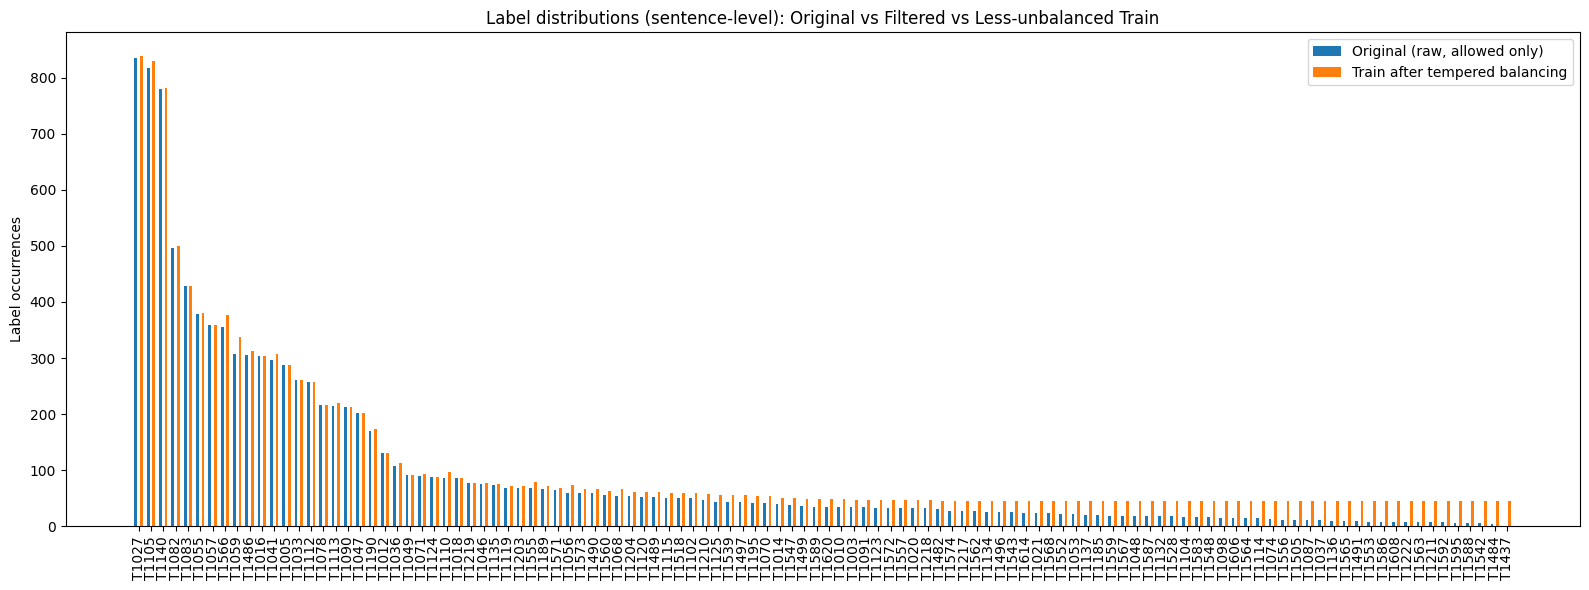

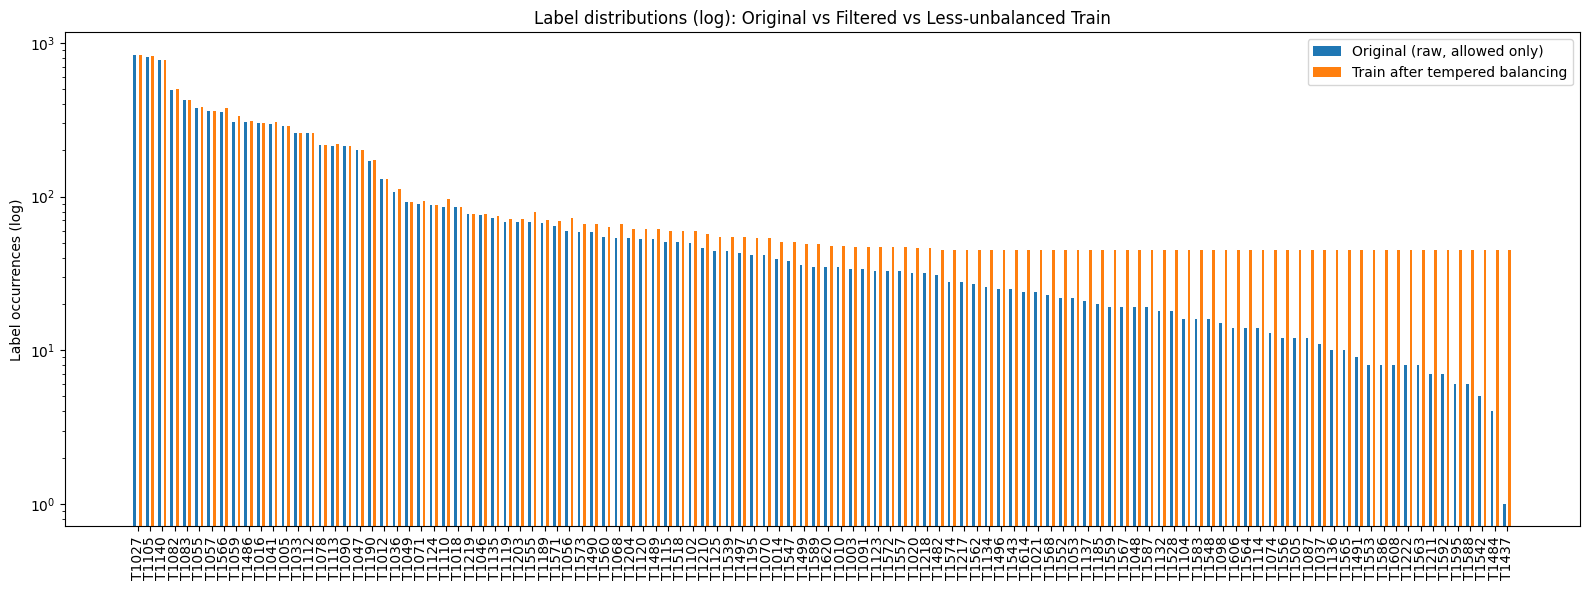

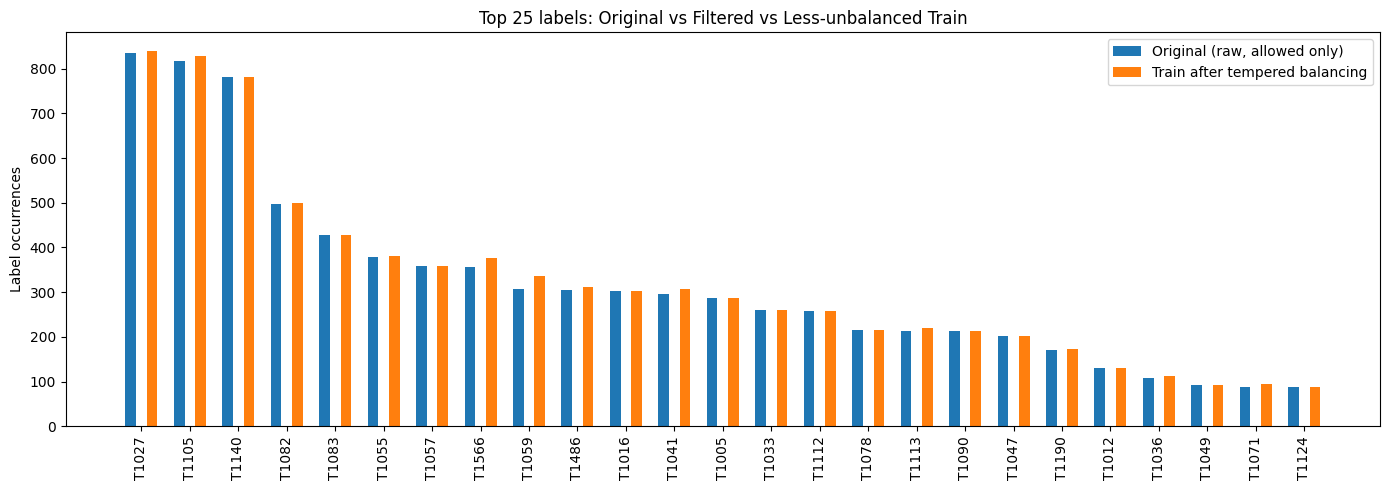

In [20]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# -------------------------
# Helpers: support dict OR tuple items
# -------------------------
def get_labels(it):
    # dict: {"sentence":..., "labels":[...]}
    if isinstance(it, dict):
        return it.get("labels", []) or []
    # tuple/list: (sentence, labels, ...)
    if isinstance(it, (list, tuple)):
        return it[1] if len(it) > 1 else []
    raise TypeError(f"Unsupported item type: {type(it)}")

def norm_labels(lbls):
    out = []
    for x in (lbls or []):
        if isinstance(x, str):
            x = x.strip()
            if x:
                out.append(x)
    return out

def count_labels_from_raw(train_data, allowed_set=None):
    c = Counter()
    for item in train_data:
        lbls = norm_labels(item.get("labels", []) or [])
        for ttp in lbls:
            if allowed_set is None or ttp in allowed_set:
                c[ttp] += 1
    return c

def count_labels_from_items(items, allowed_set=None):
    c = Counter()
    for it in items:
        lbls = norm_labels(get_labels(it))
        for ttp in lbls:
            if allowed_set is None or ttp in allowed_set:
                c[ttp] += 1
    return c

# -------------------------
# Build distributions
# -------------------------
# Original raw distribution but restricted to allowed labels
orig_counts_allowed = count_labels_from_raw(train_data, allowed_set=allowed_set)

# If you have these objects, use them; otherwise comment out what you don't have:
# - items: filtered sentence-level (unique sentences, filtered to allowed, etc.)
# - train_items_unbal: train split before balancing
# - val_items: validation split (unbalanced)
# - train_items_less_unbal: training set after tempered oversampling

# Safe fallbacks:
filtered_counts = count_labels_from_items(train_items, allowed_set=allowed_set) if "items" in globals() else Counter()
train_unbal_counts = count_labels_from_items(train_items, allowed_set=allowed_set) if "train_items_unbal" in globals() else Counter()
val_counts = count_labels_from_items(val_items, allowed_set=allowed_set) if "val_items" in globals() else Counter()
balanced_counts = count_labels_from_items(train_items_less_unbal, allowed_set=allowed_set) if "train_items_less_unbal" in globals() else Counter()

# Order labels by original allowed frequency (or by allowed_labels order if you prefer)
labels_order = [l for l, _ in orig_counts_allowed.most_common()]
# Ensure we include labels that exist only after filtering/balancing (rare)
for l in allowed_set:
    if l not in labels_order and (filtered_counts.get(l, 0) or balanced_counts.get(l, 0) or train_unbal_counts.get(l, 0)):
        labels_order.append(l)

def vals(counter):
    return [counter.get(l, 0) for l in labels_order]

orig_vals     = vals(orig_counts_allowed)
filt_vals     = vals(filtered_counts)
train_vals    = vals(train_unbal_counts)
val_vals      = vals(val_counts)
bal_vals      = vals(balanced_counts)

x = np.arange(len(labels_order))
width = 0.22

# -------------------------
# Plot 1: Original vs Filtered vs Balanced (sentence-level)
# -------------------------
plt.figure(figsize=(16, 6))
plt.bar(x - width, orig_vals, width, label="Original (raw, allowed only)")
if filtered_counts:
    plt.bar(x, filt_vals, width, label="Filtered (sentence-level)")
if balanced_counts:
    plt.bar(x + width, bal_vals, width, label="Train after tempered balancing")
plt.xticks(x, labels_order, rotation=90)
plt.ylabel("Label occurrences")
plt.title("Label distributions (sentence-level): Original vs Filtered vs Less-unbalanced Train")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot 2: Log scale
# -------------------------
plt.figure(figsize=(16, 6))
plt.bar(x - width, orig_vals, width, label="Original (raw, allowed only)")
if filtered_counts:
    plt.bar(x, filt_vals, width, label="Filtered (sentence-level)")
if balanced_counts:
    plt.bar(x + width, bal_vals, width, label="Train after tempered balancing")
plt.yscale("log")
plt.xticks(x, labels_order, rotation=90)
plt.ylabel("Label occurrences (log)")
plt.title("Label distributions (log): Original vs Filtered vs Less-unbalanced Train")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot 3 (optional): Train vs Val (both unbalanced)
# -------------------------
if train_unbal_counts and val_counts:
    plt.figure(figsize=(16, 6))
    plt.bar(x - width/2, train_vals, width, label="Train (unbalanced)")
    plt.bar(x + width/2, val_vals, width, label="Val (unbalanced)")
    plt.xticks(x, labels_order, rotation=90)
    plt.ylabel("Label occurrences")
    plt.title("Train vs Validation label distributions (unbalanced)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# Plot 4: Top-N labels (by original allowed frequency)
# -------------------------
TOP_N = 25
top_labels = labels_order[:TOP_N]
x2 = np.arange(len(top_labels))

def vals2(counter):
    return [counter.get(l, 0) for l in top_labels]

plt.figure(figsize=(14, 5))
plt.bar(x2 - width, vals2(orig_counts_allowed), width, label="Original (raw, allowed only)")
if filtered_counts:
    plt.bar(x2, vals2(filtered_counts), width, label="Filtered (sentence-level)")
if balanced_counts:
    plt.bar(x2 + width, vals2(balanced_counts), width, label="Train after tempered balancing")
plt.xticks(x2, top_labels, rotation=90)
plt.ylabel("Label occurrences")
plt.title(f"Top {TOP_N} labels: Original vs Filtered vs Less-unbalanced Train")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
def iter_sentence_label_items(sentence_items):
    """Yields (sentence, labels_list) from either dict-items or tuple-items."""
    for it in sentence_items:
        if isinstance(it, dict):
            sent = (it.get("sentence") or "").strip()
            lbls = it.get("labels", []) or []
        else:
            # tuple/list: (sent, labels, ...)
            sent = (it[0] or "").strip()
            lbls = it[1] if len(it) > 1 else []
        if not sent:
            continue
        # normalize labels
        out = []
        for x in (lbls or []):
            if isinstance(x, str):
                x = x.strip()
                if x:
                    out.append(x)
        if out:
            yield sent, out

allowed_set = set(allowed_set)
print(len(allowed_set), "allowed labels for training pairs.")
source_train_items = train_items  

train_pairs: List[Tuple[str, str]] = []
for sent, lbls in iter_sentence_label_items(source_train_items):
    for ttp in lbls:
        if ttp in allowed_set and ttp in ttp_descriptions:
            ttp_text = f"{ttp}: {ttp_descriptions[ttp]}"
            train_pairs.append((sent, ttp_text))

print(f"Training pairs (from balanced sentences): {len(train_pairs)}")

print("Sample train pair 0:", train_pairs[0])

112 allowed labels for training pairs.
Training pairs (from balanced sentences): 10764
Sample train pair 0: ('FunnyDream can check system time to help determine when changes were made to specified files.', "T1124: An adversary may gather the system time and/or time zone settings from a local or remote system. The system time is set and stored by services, such as the Windows Time Service on Windows or <code>systemsetup</code> on macOS.(Citation: MSDN System Time)(Citation: Technet Windows Time Service)(Citation: systemsetup mac time) These time settings may also be synchronized between systems and services in an enterprise network, typically accomplished with a network time server within a domain.(Citation: Mac Time Sync)(Citation: linux system time)  System time information may be gathered in a number of ways, such as with [Net](https://attack.mitre.org/software/S0039) on Windows by performing <code>net time \\\\hostname</code> to gather the system time on a remote system. The victim'

In [22]:
# 1) Basic sanity: how many items, how many yielded by iterator?
print("source_train_items:", len(source_train_items))

n_yield = 0
n_labels_total = 0
first_few = []
for sent, lbls in iter_sentence_label_items(source_train_items):
    n_yield += 1
    n_labels_total += len(lbls)
    if len(first_few) < 3:
        first_few.append((sent[:80], lbls[:10]))

print("iter_sentence_label_items yielded:", n_yield)
print("total labels across yielded items:", n_labels_total)
print("first few yields:", first_few)

# 2) Check overlap between your labels and the filters
labels_in_data = set()
for _, lbls in iter_sentence_label_items(source_train_items):
    labels_in_data.update(lbls)

print("unique labels in data:", len(labels_in_data))
print("overlap with allowed_set:", len(labels_in_data & allowed_set))
print("overlap with ttp_descriptions:", len(labels_in_data & set(ttp_descriptions.keys())))
print("overlap with BOTH:", len(labels_in_data & allowed_set & set(ttp_descriptions.keys())))

# 3) Show a few labels that are being rejected (helpful to see formatting issues)
rejected_allowed = list(labels_in_data - allowed_set)[:20]
rejected_desc = list(labels_in_data - set(ttp_descriptions.keys()))[:20]
print("example labels not in allowed_set:", rejected_allowed)
print("example labels not in ttp_descriptions:", rejected_desc)



source_train_items: 10017
iter_sentence_label_items yielded: 10017
total labels across yielded items: 10764
first few yields: [('FunnyDream can check system time to help determine when changes were made to spe', ['T1124']), ('Turian can search for specific files and list directories.', ['T1083']), ('SVCReady can check for the number of devices plugged into an infected host.', ['T1120'])]
unique labels in data: 112
overlap with allowed_set: 112
overlap with ttp_descriptions: 112
overlap with BOTH: 112
example labels not in allowed_set: []
example labels not in ttp_descriptions: []


In [13]:
# 1) Basic sanity: how many items, how many yielded by iterator?
print("source_train_items:", len(source_train_items))

n_yield = 0
n_labels_total = 0
first_few = []
for sent, lbls in iter_sentence_label_items(source_train_items):
    n_yield += 1
    n_labels_total += len(lbls)
    if len(first_few) < 3:
        first_few.append((sent[:80], lbls[:10]))

print("iter_sentence_label_items yielded:", n_yield)
print("total labels across yielded items:", n_labels_total)
print("first few yields:", first_few)

# 2) Check overlap between your labels and the filters
labels_in_data = set()
for _, lbls in iter_sentence_label_items(source_train_items):
    labels_in_data.update(lbls)

print("unique labels in data:", len(labels_in_data))
print("overlap with allowed_set:", len(labels_in_data & allowed_set))
print("overlap with ttp_descriptions:", len(labels_in_data & set(ttp_descriptions.keys())))
print("overlap with BOTH:", len(labels_in_data & allowed_set & set(ttp_descriptions.keys())))

# 3) Show a few labels that are being rejected (helpful to see formatting issues)
rejected_allowed = list(labels_in_data - allowed_set)[:20]
rejected_desc = list(labels_in_data - set(ttp_descriptions.keys()))[:20]
print("example labels not in allowed_set:", rejected_allowed)
print("example labels not in ttp_descriptions:", rejected_desc)


source_train_items: 13316
iter_sentence_label_items yielded: 13316
total labels across yielded items: 14678
first few yields: [('Turian can search for specific files and list directories.', ['T1083']), ('VIRTUALPITA samples have been found in `/usr/libexec/setconf/ksmd` and `/usr/bin', ['T1036.005']), ('For the Standard IcedID Bot, this value is set to 119 as seen above, but for the', ['T1140'])]
unique labels in data: 50
overlap with allowed_set: 50
overlap with ttp_descriptions: 50
overlap with BOTH: 50
example labels not in allowed_set: []
example labels not in ttp_descriptions: []


In [23]:

with open(VALIDATION_DATA_PATH, "r", encoding="utf-8") as f:
    val_data = json.load(f)   # list of {"sentence":..., "labels":[...]}

# -------------------------
# DATASET + COLLATE
# -------------------------
class PairDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str, str]]):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx: int):
        return self.pairs[idx]  # (sent, ttp_text)

@dataclass
class DualCollator:
    tokenizer: object
    max_len_sent: int
    max_len_ttp: int

    def __call__(self, batch: List[Tuple[str, str]]) -> Dict[str, Dict[str, torch.Tensor]]:
        sents = [b[0] for b in batch]
        ttps  = [b[1] for b in batch]

        tok_sent = self.tokenizer(
            sents,
            padding=True,
            truncation=True,
            max_length=self.max_len_sent,
            return_tensors="pt",
        )
        tok_ttp = self.tokenizer(
            ttps,
            padding=True,
            truncation=True,
            max_length=self.max_len_ttp,
            return_tensors="pt",
        )
        return {"sent": tok_sent, "ttp": tok_ttp}

# -------------------------
# MODEL: SecureBERT bi-encoder
# -------------------------
class SecureBertEmbedder(nn.Module):
    def __init__(self, model_name: str):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)

    @staticmethod
    def mean_pool(last_hidden: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).type_as(last_hidden)
        summed = (last_hidden * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-9)
        return summed / denom

    def encode_batch(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        emb = self.mean_pool(out.last_hidden_state, attention_mask)
        emb = F.normalize(emb, p=2, dim=1)
        return emb

    @torch.no_grad()
    def encode_texts(self, tokenizer, texts: List[str], batch_size: int, max_length: int) -> np.ndarray:
        self.eval()
        all_embs = []
        for i in range(0, len(texts), batch_size):
            chunk = texts[i:i+batch_size]
            tok = tokenizer(
                chunk,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            tok = {k: v.to(DEVICE) for k, v in tok.items()}
            embs = self.encode_batch(tok["input_ids"], tok["attention_mask"])
            all_embs.append(embs.detach().cpu().numpy())
        return np.vstack(all_embs)

# -------------------------
# LOSS: In-batch negatives
# -------------------------
class InBatchNegativesLoss(nn.Module):
    def __init__(self, temperature: float = 0.05):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_a: torch.Tensor, emb_b: torch.Tensor) -> torch.Tensor:
        logits = (emb_a @ emb_b.t()) / self.temperature
        labels = torch.arange(logits.size(0), device=logits.device)
        return F.cross_entropy(logits, labels)

# -------------------------
# TOKENIZER / DATALOADER
# -------------------------
# IMPORTANT: use AutoTokenizer for SecureBERT
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

train_ds = PairDataset(train_pairs)
collator = DualCollator(tokenizer=tokenizer, max_len_sent=MAX_LEN_SENT, max_len_ttp=MAX_LEN_TTP)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collator
)

# -------------------------
# INIT MODEL / OPT / SCHED
# -------------------------
model = SecureBertEmbedder(BASE_MODEL).to(DEVICE)
loss_fn = InBatchNegativesLoss(temperature=TEMPERATURE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# -------------------------
# PREP VAL TTP TEXTS
# -------------------------
allowed_set = set(allowed_set) 
ttp_ids = [t for t in allowed_set if t in ttp_descriptions]   # keeps the allowed order ttp_texts = [f"{t}: {ttp_descriptions[t]}" for t in ttp_ids]
ttp_texts = [f"{t}: {ttp_descriptions[t]}" for t in ttp_ids]

# -------------------------
# VALIDATION FUNCTION
# -------------------------
def get_val_sentence(item):
    if isinstance(item, dict):
        return (item.get("sentence") or "").strip()
    if isinstance(item, (list, tuple)):
        return (item[0] or "").strip()
    raise TypeError(f"Unsupported val item type: {type(item)}")

def get_val_labels(item):
    if isinstance(item, dict):
        return item.get("labels", []) or []
    if isinstance(item, (list, tuple)):
        return item[1] if len(item) > 1 else []
    raise TypeError(f"Unsupported val item type: {type(item)}")

def validate(model: SecureBertEmbedder, k_list=(1, 5, 10)) -> Dict[str, float]:
    model.eval()

    ttp_embs = model.encode_texts(tokenizer, ttp_texts, batch_size=64, max_length=MAX_LEN_TTP)

    hits_at_k = {k: 0 for k in k_list}
    mean_recall_at_k = {k: 0.0 for k in k_list}
    mrr = 0.0
    used = 0

    for item in val_data:
        sent = get_val_sentence(item)
        raw_lbls = get_val_labels(item)

        gold = {t.strip() for t in raw_lbls if isinstance(t, str) and t.strip()}
        gold = {t for t in gold if t in allowed_set and t in ttp_descriptions}
        if not sent or not gold:
            continue

        used += 1

        sent_emb = model.encode_texts(tokenizer, [sent], batch_size=1, max_length=MAX_LEN_SENT)[0]
        sims = cosine_similarity(sent_emb.reshape(1, -1), ttp_embs)[0]
        ranking = np.argsort(-sims)

        rr = 0.0
        for rank_pos, idx in enumerate(ranking, start=1):
            if ttp_ids[idx] in gold:
                rr = 1.0 / rank_pos
                break
        mrr += rr

        for k in k_list:
            topk = [ttp_ids[i] for i in ranking[:k]]
            hits_at_k[k] += int(any(t in gold for t in topk))
            mean_recall_at_k[k] += len(set(topk) & gold) / max(1, len(gold))

    n = max(1, used)
    metrics = {f"hit@{k}": hits_at_k[k] / n for k in k_list}
    metrics.update({f"mean_recall@{k}": mean_recall_at_k[k] / n for k in k_list})
    metrics["mrr"] = mrr / n
    metrics["val_used"] = used
    return metrics



# -------------------------
# SAVE HELPERS
# -------------------------
def save_model(model: SecureBertEmbedder, tokenizer, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    model.backbone.save_pretrained(out_dir)
    tokenizer.save_pretrained(out_dir)

# -------------------------
# TRAIN LOOP WITH EARLY STOPPING
# -------------------------
best_score = -1.0
patience_ctr = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running = 0.0

    print(f"\nEpoch {epoch}")

    for batch in train_loader:
        tok_sent = {k: v.to(DEVICE) for k, v in batch["sent"].items()}
        tok_ttp  = {k: v.to(DEVICE) for k, v in batch["ttp"].items()}

        emb_sent = model.encode_batch(tok_sent["input_ids"], tok_sent["attention_mask"])
        emb_ttp  = model.encode_batch(tok_ttp["input_ids"], tok_ttp["attention_mask"])

        loss = loss_fn(emb_sent, emb_ttp)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        running += loss.item()

    avg_loss = running / max(1, len(train_loader))
    metrics = validate(model)
    print(f"Train loss: {avg_loss:.4f}")
    print("Validation:", ", ".join([f"{k}: {v:.4f}" for k, v in metrics.items()]))

    score = metrics["hit@1"]

    if score > best_score:
        best_score = score
        patience_ctr = 0
        save_model(model, tokenizer, OUTPUT_DIR)
        print("✔ New best model saved")
    else:
        patience_ctr += 1
        print(f"No improvement (patience {patience_ctr}/{PATIENCE})")

    if patience_ctr >= PATIENCE:
        print("\nEarly stopping triggered")
        break

print(f"\nBest validation hit@1: {best_score:.4f}")
print(f"Saved to: {OUTPUT_DIR}")


Some weights of RobertaModel were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1
Train loss: 2.1254
Validation: hit@1: 0.6490, hit@5: 0.8898, hit@10: 0.9339, mean_recall@1: 0.6286, mean_recall@5: 0.8774, mean_recall@10: 0.9257, mrr: 0.7542, val_used: 1134.0000
✔ New best model saved

Epoch 2
Train loss: 1.2062
Validation: hit@1: 0.7178, hit@5: 0.9206, hit@10: 0.9568, mean_recall@1: 0.6925, mean_recall@5: 0.9094, mean_recall@10: 0.9484, mrr: 0.8062, val_used: 1134.0000
✔ New best model saved

Epoch 3
Train loss: 1.0474
Validation: hit@1: 0.7451, hit@5: 0.9321, hit@10: 0.9647, mean_recall@1: 0.7181, mean_recall@5: 0.9188, mean_recall@10: 0.9572, mrr: 0.8266, val_used: 1134.0000
✔ New best model saved

Epoch 4
Train loss: 0.9629
Validation: hit@1: 0.7725, hit@5: 0.9436, hit@10: 0.9700, mean_recall@1: 0.7457, mean_recall@5: 0.9325, mean_recall@10: 0.9631, mrr: 0.8450, val_used: 1134.0000
✔ New best model saved

Epoch 5
Train loss: 0.8759
Validation: hit@1: 0.7848, hit@5: 0.9550, hit@10: 0.9753, mean_recall@1: 0.7576, mean_recall@5: 0.9434, mean_recall@10: 0.96

In [ ]:
print("train_items:", len(train_items) if "train_items" in globals() else None)
print("allowed_set:", len(allowed_set))
print("ttp_descriptions:", len(ttp_descriptions))

# how many labels in train items overlap allowed?
from collections import Counter
tmp = Counter()
for sent, lbls in iter_sentence_label_items(train_items):
    tmp.update(lbls)

print("unique labels in train_items:", len(tmp))
print("overlap(train_labels, allowed):", len(set(tmp) & set(allowed_set)))
print("overlap(train_labels, ttp_descriptions):", len(set(tmp) & set(ttp_descriptions)))
# Show a few example labels from train and a few keys from ttp_descriptions
train_label_sample = sorted(list(set(lbl for _, lbls in train_items for lbl in lbls)))[:100]
desc_key_sample = list(ttp_descriptions.keys())[:20]

print("Train label sample:", train_label_sample)
print("Desc key sample  :", desc_key_sample)


train_items_less_unbal: 10464
allowed_set: 50
ttp_descriptions: 836
unique labels in train_items_less_unbal: 111
overlap(train_labels, allowed): 22
overlap(train_labels, ttp_descriptions): 111
Train label sample: ['T1003', 'T1005', 'T1010', 'T1012', 'T1014', 'T1016', 'T1018', 'T1020', 'T1021', 'T1027', 'T1033', 'T1036', 'T1037', 'T1041', 'T1046', 'T1047', 'T1048', 'T1049', 'T1053', 'T1055', 'T1056', 'T1057', 'T1059', 'T1068', 'T1070', 'T1071', 'T1074', 'T1078', 'T1082', 'T1083', 'T1087', 'T1090', 'T1091', 'T1098', 'T1102', 'T1104', 'T1105', 'T1110', 'T1112', 'T1113', 'T1114', 'T1115', 'T1119', 'T1120', 'T1123', 'T1124', 'T1125', 'T1132', 'T1134', 'T1135', 'T1136', 'T1137', 'T1140', 'T1185', 'T1189', 'T1190', 'T1195', 'T1203', 'T1204', 'T1210', 'T1211', 'T1217', 'T1218', 'T1219', 'T1222', 'T1482', 'T1484', 'T1486', 'T1489', 'T1490', 'T1491', 'T1496', 'T1497', 'T1499', 'T1505', 'T1518', 'T1528', 'T1539', 'T1542', 'T1543', 'T1547', 'T1548', 'T1552', 'T1553', 'T1555', 'T1556', 'T1557', 'T1

In [77]:
from collections import Counter

in_sent_level = set()
in_pairs = set()
missing_desc = set()
not_allowed = set()

# Optional: count how often each label appears
sent_label_counts = Counter()

for sent, lbls in iter_sentence_label_items(source_train_items):
    for ttp in lbls:
        if ttp in allowed_set:
            in_sent_level.add(ttp)
            sent_label_counts[ttp] += 1
            if ttp in ttp_descriptions:
                in_pairs.add(ttp)
            else:
                missing_desc.add(ttp)
        else:
            not_allowed.add(ttp)

print(f"Sentence-level unique labels (allowed_set): {len(in_sent_level)}")
print(f"Pair-usable unique labels (also in ttp_descriptions): {len(in_pairs)}")
print(f"Allowed but MISSING in ttp_descriptions: {len(missing_desc)}")
print(f"Not in allowed_set (should be 0 if source is already filtered): {len(not_allowed)}")

# Show the top missing ones by frequency
top_missing = sorted(missing_desc, key=lambda t: sent_label_counts[t], reverse=True)[:30]
print("\nTop missing_desc labels (by frequency in train sentences):")
for t in top_missing:
    print(t, "count_in_sentences:", sent_label_counts[t])

# Quick check: are you missing sub-techniques because of formatting?
print("\nExamples of missing_desc labels:", sorted(list(missing_desc))[:25])
print("Example keys in ttp_descriptions:", list(ttp_descriptions.keys())[:10])


Sentence-level unique labels (allowed_set): 50
Pair-usable unique labels (also in ttp_descriptions): 50
Allowed but MISSING in ttp_descriptions: 0
Not in allowed_set (should be 0 if source is already filtered): 0

Top missing_desc labels (by frequency in train sentences):

Examples of missing_desc labels: []
Example keys in ttp_descriptions: ['T1055.011', 'T1053.005', 'T1205.002', 'T1066', 'T1560.001', 'T1021.005', 'T1047', 'T1156', 'T1113', 'T1027.011']


# clean + unique + stable order
in_pairs = [x.strip() for x in in_pairs if isinstance(x, str) and x.strip()]
in_pairs = sorted(set(in_pairs))

out_path = "/home/simonettos/thijs/data_augmentatio_stefano/siamese_unsup_sup/allowed_labels_tram.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump({"labels": in_pairs}, f, indent=2)

print(f"Wrote {len(in_pairs)} labels -> {out_path}")


Siamese4bosch

Some weights of RobertaModel were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Epoch 1
Train loss: 2.4638
Validation: hit@1: 0.6741, hit@5: 0.9277, hit@10: 0.9603, mean_recall@1: 0.6472, mean_recall@5: 0.9129, mean_recall@10: 0.9523, mrr: 0.7821, val_used: 1258.0000
✔ New best model saved

Epoch 2
Train loss: 1.5001
Validation: hit@1: 0.7297, hit@5: 0.9420, hit@10: 0.9722, mean_recall@1: 0.7008, mean_recall@5: 0.9269, mean_recall@10: 0.9644, mrr: 0.8225, val_used: 1258.0000
✔ New best model saved

Epoch 3
Train loss: 1.3812
Validation: hit@1: 0.7560, hit@5: 0.9459, hit@10: 0.9690, mean_recall@1: 0.7255, mean_recall@5: 0.9300, mean_recall@10: 0.9627, mrr: 0.8391, val_used: 1258.0000
✔ New best model saved

Epoch 4
Train loss: 1.3222
Validation: hit@1: 0.7512, hit@5: 0.9380, hit@10: 0.9722, mean_recall@1: 0.7210, mean_recall@5: 0.9235, mean_recall@10: 0.9650, mrr: 0.8336, val_used: 1258.0000
No improvement (patience 1/5)

Epoch 5
Train loss: 1.2589
Validation: hit@1: 0.7424, hit@5: 0.9253, hit@10: 0.9690, mean_recall@1: 0.7122, mean_recall@5: 0.9107, mean_recall@10: 0.9583, mrr: 0.8253, val_used: 1258.0000
No improvement (patience 2/5)

Epoch 6
Train loss: 1.2096
Validation: hit@1: 0.7353, hit@5: 0.9197, hit@10: 0.9666, mean_recall@1: 0.7038, mean_recall@5: 0.9029, mean_recall@10: 0.9571, mrr: 0.8184, val_used: 1258.0000
No improvement (patience 3/5)

Epoch 7
Train loss: 1.1993
Validation: hit@1: 0.7393, hit@5: 0.9293, hit@10: 0.9642, mean_recall@1: 0.7078, mean_recall@5: 0.9113, mean_recall@10: 0.9545, mrr: 0.8204, val_used: 1258.0000
No improvement (patience 4/5)

Epoch 8
Train loss: 1.1698
Validation: hit@1: 0.7456, hit@5: 0.9300, hit@10: 0.9682, mean_recall@1: 0.7130, mean_recall@5: 0.9111, mean_recall@10: 0.9597, mrr: 0.8292, val_used: 1258.0000
No improvement (patience 5/5)

Early stopping triggered

Best validation hit@1: 0.7560
Saved to: /home/simonettos/thijs/data_augmentatio_stefano/mitre/siamese_sentence_ttp_model_bosch

Siamese 4 TRAM

Some weights of RobertaModel were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Epoch 1
Train loss: 1.8970
Validation: hit@1: 0.8072, hit@5: 0.9586, hit@10: 0.9769, mean_recall@1: 0.7792, mean_recall@5: 0.9498, mean_recall@10: 0.9731, mrr: 0.8759, val_used: 1255.0000
✔ New best model saved

Epoch 2
Train loss: 1.0357
Validation: hit@1: 0.8438, hit@5: 0.9681, hit@10: 0.9833, mean_recall@1: 0.8154, mean_recall@5: 0.9622, mean_recall@10: 0.9807, mrr: 0.8988, val_used: 1255.0000
✔ New best model saved

Epoch 3
Train loss: 0.9183
Validation: hit@1: 0.8757, hit@5: 0.9657, hit@10: 0.9865, mean_recall@1: 0.8453, mean_recall@5: 0.9604, mean_recall@10: 0.9843, mrr: 0.9168, val_used: 1255.0000
✔ New best model saved

Epoch 4
Train loss: 0.8327
Validation: hit@1: 0.8606, hit@5: 0.9665, hit@10: 0.9904, mean_recall@1: 0.8305, mean_recall@5: 0.9616, mean_recall@10: 0.9876, mrr: 0.9102, val_used: 1255.0000
No improvement (patience 1/5)

Epoch 5
Train loss: 0.7737
Validation: hit@1: 0.8741, hit@5: 0.9745, hit@10: 0.9857, mean_recall@1: 0.8453, mean_recall@5: 0.9708, mean_recall@10: 0.9833, mrr: 0.9198, val_used: 1255.0000
No improvement (patience 2/5)

Epoch 6
Train loss: 0.7553
Validation: hit@1: 0.8765, hit@5: 0.9705, hit@10: 0.9865, mean_recall@1: 0.8469, mean_recall@5: 0.9677, mean_recall@10: 0.9845, mrr: 0.9216, val_used: 1255.0000
✔ New best model saved

Epoch 7
Train loss: 0.7216
Validation: hit@1: 0.8789, hit@5: 0.9737, hit@10: 0.9880, mean_recall@1: 0.8493, mean_recall@5: 0.9702, mean_recall@10: 0.9862, mrr: 0.9236, val_used: 1255.0000
✔ New best model saved

Epoch 8
Train loss: 0.6951
Validation: hit@1: 0.8845, hit@5: 0.9753, hit@10: 0.9880, mean_recall@1: 0.8541, mean_recall@5: 0.9718, mean_recall@10: 0.9857, mrr: 0.9257, val_used: 1255.0000
✔ New best model saved

Epoch 9
Train loss: 0.6821
Validation: hit@1: 0.8853, hit@5: 0.9737, hit@10: 0.9873, mean_recall@1: 0.8556, mean_recall@5: 0.9687, mean_recall@10: 0.9858, mrr: 0.9253, val_used: 1255.0000
✔ New best model saved

Epoch 10
Train loss: 0.6832
Validation: hit@1: 0.8853, hit@5: 0.9737, hit@10: 0.9904, mean_recall@1: 0.8548, mean_recall@5: 0.9694, mean_recall@10: 0.9878, mrr: 0.9260, val_used: 1255.0000
No improvement (patience 1/5)

Epoch 11
Train loss: 0.6600
Validation: hit@1: 0.8869, hit@5: 0.9745, hit@10: 0.9873, mean_recall@1: 0.8568, mean_recall@5: 0.9704, mean_recall@10: 0.9849, mrr: 0.9275, val_used: 1255.0000
✔ New best model saved

Epoch 12
Train loss: 0.6556
Validation: hit@1: 0.8916, hit@5: 0.9697, hit@10: 0.9880, mean_recall@1: 0.8612, mean_recall@5: 0.9660, mean_recall@10: 0.9862, mrr: 0.9289, val_used: 1255.0000
✔ New best model saved

Epoch 13
Train loss: 0.6472
Validation: hit@1: 0.8829, hit@5: 0.9761, hit@10: 0.9880, mean_recall@1: 0.8525, mean_recall@5: 0.9725, mean_recall@10: 0.9857, mrr: 0.9254, val_used: 1255.0000
No improvement (patience 1/5)

Epoch 14
Train loss: 0.6441
Validation: hit@1: 0.8861, hit@5: 0.9785, hit@10: 0.9888, mean_recall@1: 0.8548, mean_recall@5: 0.9746, mean_recall@10: 0.9873, mrr: 0.9270, val_used: 1255.0000
No improvement (patience 2/5)

Epoch 15
Train loss: 0.6388
Validation: hit@1: 0.8876, hit@5: 0.9745, hit@10: 0.9841, mean_recall@1: 0.8584, mean_recall@5: 0.9707, mean_recall@10: 0.9818, mrr: 0.9275, val_used: 1255.0000
No improvement (patience 3/5)

Epoch 16
Train loss: 0.6272
Validation: hit@1: 0.8853, hit@5: 0.9737, hit@10: 0.9857, mean_recall@1: 0.8548, mean_recall@5: 0.9701, mean_recall@10: 0.9829, mrr: 0.9257, val_used: 1255.0000
No improvement (patience 4/5)

Epoch 17
Train loss: 0.6316
Validation: hit@1: 0.8876, hit@5: 0.9737, hit@10: 0.9896, mean_recall@1: 0.8576, mean_recall@5: 0.9697, mean_recall@10: 0.9876, mrr: 0.9291, val_used: 1255.0000
No improvement (patience 5/5)

Early stopping triggered

Best validation hit@1: 0.8916
Saved to: /home/simonettos/thijs/data_augmentatio_stefano/mitre/siamese_sentence_ttp_model_tram